# 03 — Model Evaluation

**Belgium Campus · Student Academic Risk Prediction**

> **How well does the saved model predict academic risk — and where does it fail?**

---
## 1. Project Overview

| Item | Detail |
|------|--------|
| Task | `Low` / `Medium` / `High` risk |
| Model | `models/trained_model.pkl` |
| Holdout | Stratified 20%, `random_state=42` |

---
## 2. Import Libraries

In [13]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_recall_fscore_support, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2
RISK_ORDER = ["Low", "Medium", "High"]
RISK_COLORS = {"Low": "#2a9d8f", "Medium": "#e9c46a", "High": "#e76f51"}
LEAKAGE_OR_ID_COLS = ["student_id", "profile", "risk_score", "risk_label"]
print("Libraries imported.")

Libraries imported.


---
## 3. Load Dataset

In [14]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "synthetic" / "students.csv"
MODEL_DIR = PROJECT_ROOT / "models"

df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c not in LEAKAGE_OR_ID_COLS]
X = df[feature_cols].copy()
y = df["risk_label"].map({l: i for i, l in enumerate(RISK_ORDER)}).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
_, df_test, _, _ = train_test_split(
    df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Features: {feature_cols}")
print(f"Train {len(X_train):,} | Test {len(X_test):,}")
display(df.head(3))

Features: ['age', 'gender', 'programme', 'specialisation', 'year_of_study', 'attendance', 'assignment_completion', 'bc_connect_activity', 'missed_assessments', 'overall_average', 'midyear_average', 'test_average', 'assignment_average', 'practical_average', 'failed_modules', 'registered_modules', 'passed_modules']
Train 1,600 | Test 400


,student_id,profile,age,gender,programme,specialisation,year_of_study,attendance,assignment_completion,bc_connect_activity,...,overall_average,midyear_average,test_average,assignment_average,practical_average,failed_modules,registered_modules,passed_modules,risk_score,risk_label
0,STU00001,average,28,Male,Bachelor of Information Technology,Software Development,Third Year,86,82,14,...,63.4,59.7,68.3,66.0,64.6,1,5,4,47.70,Medium
1,STU00002,thriving,22,Female,Bachelor of Computing,Software Engineering,First Year,95,96,24,...,84.6,85.3,84.7,91.2,84.2,0,5,5,11.02,Low
2,STU00003,thriving,20,Female,Higher Certificate in Information Systems,Information Systems,First Year,92,100,20,...,82.6,78.8,89.7,84.6,83.0,0,4,4,18.56,Low


---
## 4. Load Saved Model

In [15]:
model = joblib.load(MODEL_DIR / "trained_model.pkl")
label_encoder = joblib.load(MODEL_DIR / "label_encoder.pkl")
estimator = model.named_steps["model"]
estimator_name = type(estimator).__name__
print(f"Estimator: {estimator_name}")
print(f"Classes: {list(label_encoder.classes_)}")
display(model)

Estimator: LogisticRegression
Classes: [np.str_('Low'), np.str_('Medium'), np.str_('High')]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['age','gender','programme',...,'failed_modules','registered_modules', 'passed_modules']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

---
## 5. Make Predictions

In [16]:
y_pred = model.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)
display(pd.DataFrame({
    "actual": y_test_labels[:10],
    "predicted": y_pred_labels[:10],
    "correct": y_test_labels[:10] == y_pred_labels[:10],
}))
print(f"Correct: {int((y_pred == y_test).sum())} / {len(y_test)}")

,actual,predicted,correct
0,Medium,Medium,True
1,Low,Low,True
2,Low,Low,True
3,Medium,Medium,True
4,High,High,True
5,Low,Medium,False
6,Medium,Medium,True
7,Medium,Medium,True
8,Medium,Medium,True
9,Low,Low,True


Correct: 383 / 400


---
## 6. Accuracy

In [17]:
accuracy = accuracy_score(y_test, y_pred)
display(pd.DataFrame({
    "metric": ["accuracy"],
    "value": [round(accuracy, 4)],
    "interpretation": [f"{accuracy:.1%} of held-out students correct"],
}))

,metric,value,interpretation
0,accuracy,0.9575,95.8% of held-out students correct


---
## 7. Precision, Recall & F1

,risk_label,precision,recall,f1,support
0,Low,0.970,0.908,0.938,142
1,Medium,0.913,0.971,0.941,140
2,High,1.000,1.000,1.000,118


,precision_macro,recall_macro,f1_macro,f1_weighted
0,0.9609,0.96,0.9598,0.9575


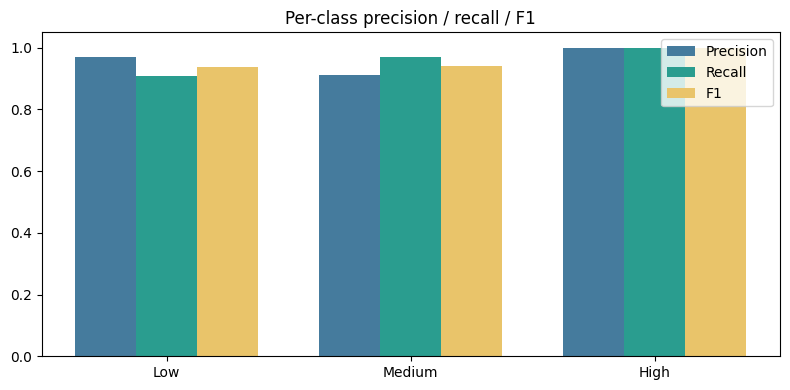

In [18]:
order_idx = [list(label_encoder.classes_).index(r) for r in RISK_ORDER]
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=order_idx, zero_division=0
)
per_class = pd.DataFrame({
    "risk_label": RISK_ORDER,
    "precision": np.round(precision, 3),
    "recall": np.round(recall, 3),
    "f1": np.round(f1, 3),
    "support": support,
})
macro = {
    "precision_macro": round(precision_score(y_test, y_pred, average="macro"), 4),
    "recall_macro": round(recall_score(y_test, y_pred, average="macro"), 4),
    "f1_macro": round(f1_score(y_test, y_pred, average="macro"), 4),
    "f1_weighted": round(f1_score(y_test, y_pred, average="weighted"), 4),
}
display(per_class)
display(pd.DataFrame([macro]))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.25
ax.bar(x - w, precision, w, label="Precision", color="#457b9d")
ax.bar(x, recall, w, label="Recall", color="#2a9d8f")
ax.bar(x + w, f1, w, label="F1", color="#e9c46a")
ax.set_xticks(x, RISK_ORDER)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Per-class precision / recall / F1")
plt.tight_layout()
plt.show()

---
## 8. Classification Report

In [19]:
print(classification_report(
    y_test, y_pred, labels=order_idx, target_names=RISK_ORDER, digits=3, zero_division=0
))

              precision    recall  f1-score   support

         Low      0.970     0.908     0.938       142
      Medium      0.913     0.971     0.941       140
        High      1.000     1.000     1.000       118

    accuracy                          0.958       400
   macro avg      0.961     0.960     0.960       400
weighted avg      0.959     0.958     0.957       400



---
## 9. Confusion Matrix

,Pred Low,Pred Medium,Pred High
Actual Low,129,13,0
Actual Medium,4,136,0
Actual High,0,0,118


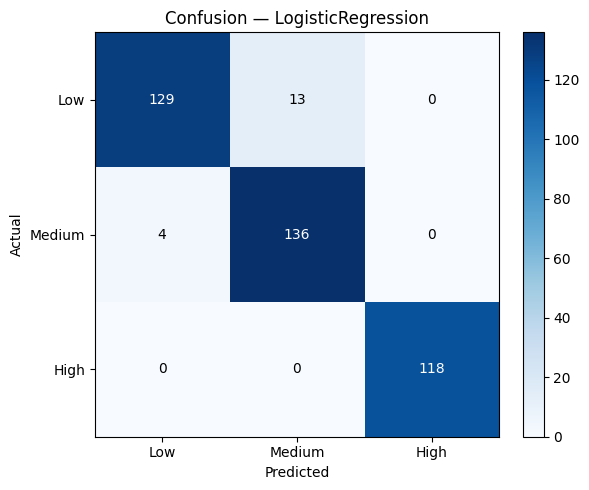

High-risk misses: 0


In [20]:
cm = confusion_matrix(y_test, y_pred, labels=order_idx)
display(pd.DataFrame(cm, index=[f"Actual {r}" for r in RISK_ORDER],
                     columns=[f"Pred {r}" for r in RISK_ORDER]))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), RISK_ORDER)
ax.set_yticks(range(3), RISK_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion — {estimator_name}")
thresh = cm.max() / 2 if cm.max() else 0
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

high_idx = RISK_ORDER.index("High")
high_misses = int(cm[high_idx].sum() - cm[high_idx, high_idx])
print(f"High-risk misses: {high_misses}")

---
## 10. Feature Importance

Source: mean_|coef_|


,feature,importance
0,num__missed_assessments,1.710053
1,num__failed_modules,1.524548
2,num__overall_average,1.091758
3,num__midyear_average,1.038211
4,num__passed_modules,1.017617
5,num__test_average,0.988639
6,num__bc_connect_activity,0.987354
7,num__practical_average,0.892361
8,num__attendance,0.832258
9,num__assignment_average,0.814783


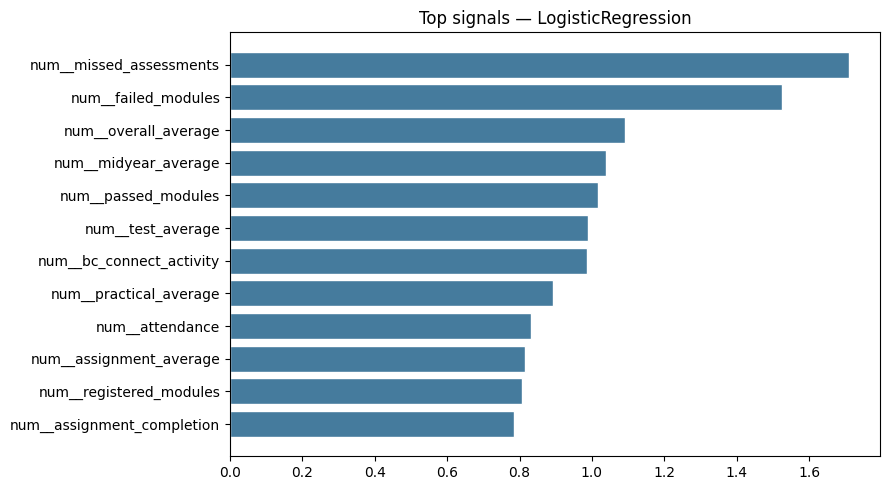

In [21]:
preprocess = model.named_steps["preprocess"]
feature_names = preprocess.get_feature_names_out()
if hasattr(estimator, "feature_importances_"):
    importances = estimator.feature_importances_
    kind = "feature_importances_"
elif hasattr(estimator, "coef_"):
    coef = np.asarray(estimator.coef_)
    importances = np.mean(np.abs(coef), axis=0) if coef.ndim == 2 else np.abs(coef)
    kind = "mean_|coef_|"
else:
    raise AttributeError(estimator_name)

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False).reset_index(drop=True)
)
print(f"Source: {kind}")
display(importance_df.head(15))

top = importance_df.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["feature"], top["importance"], color="#457b9d", edgecolor="white")
ax.set_title(f"Top signals — {estimator_name}")
plt.tight_layout()
plt.show()

---
## 11. Example Predictions

In [22]:
examples = df_test.copy()
examples["actual"] = y_test_labels
examples["predicted"] = y_pred_labels
examples["correct"] = examples["actual"] == examples["predicted"]

show_cols = [
    "student_id", "programme", "specialisation", "year_of_study",
    "attendance", "assignment_completion", "test_average", "midyear_average",
    "bc_connect_activity", "missed_assessments", "failed_modules",
    "actual", "predicted",
]

print("Correct (sample):")
display(examples.loc[examples["correct"], show_cols].head(5))
print("Incorrect (sample):")
mistakes = examples.loc[~examples["correct"], show_cols]
display(mistakes.head(5) if len(mistakes) else pd.DataFrame({"note": ["None"]}))
print("High-risk misses:")
hm = examples[(examples["actual"] == "High") & (examples["predicted"] != "High")]
display(hm[show_cols].head(5) if len(hm) else pd.DataFrame({"note": ["None"]}))

Correct (sample):


,student_id,programme,specialisation,year_of_study,attendance,assignment_completion,test_average,midyear_average,bc_connect_activity,missed_assessments,failed_modules,actual,predicted
876,STU00877,Diploma in Information Technology,Cybersecurity,Second Year,73,78,62.3,63.0,14,0,1,Medium,Medium
1128,STU01129,Higher Certificate in Information Systems,Systems Support,First Year,93,98,95.2,78.4,25,0,0,Low,Low
548,STU00549,Higher Certificate in Information Systems,Systems Support,First Year,89,96,87.4,81.7,23,0,0,Low,Low
1794,STU01795,Bachelor of Information Technology,Data Science,Second Year,72,88,69.2,61.9,8,0,0,Medium,Medium
897,STU00898,Bachelor of Information Technology,Cybersecurity,First Year,70,59,53.5,51.8,2,3,1,High,High


Incorrect (sample):


,student_id,programme,specialisation,year_of_study,attendance,assignment_completion,test_average,midyear_average,bc_connect_activity,missed_assessments,failed_modules,actual,predicted
831,STU00832,Bachelor of Information Technology,Cloud Computing,Fourth Year,89,87,63.0,70.1,5,0,0,Low,Medium
258,STU00259,Higher Certificate in Information Systems,Information Systems,First Year,81,86,68.3,63.9,11,0,0,Low,Medium
219,STU00220,Bachelor of Computing,Artificial Intelligence,Fourth Year,81,90,66.9,59.3,10,0,0,Low,Medium
1308,STU01309,Diploma in Information Technology,Software Development,Second Year,83,85,77.6,61.8,11,1,0,Low,Medium
1750,STU01751,Diploma in Information Technology,Network Engineering,First Year,75,77,61.1,71.0,9,0,0,Medium,Low


High-risk misses:


,note
0,None


---
## 12. Model Strengths & Limitations

In [23]:
high_recall = float(per_class.loc[per_class["risk_label"] == "High", "recall"].iloc[0])
medium_f1 = float(per_class.loc[per_class["risk_label"] == "Medium", "f1"].iloc[0])
display(pd.DataFrame({
    "type": ["Strength", "Strength", "Limitation", "Limitation"],
    "point": [
        f"Test accuracy {accuracy:.1%}; High recall {high_recall:.1%}",
        "Uses BC-style predictors (attendance, completion, BC Connect, misses, fails)",
        f"Medium class often hardest (F1={medium_f1:.1%})",
        "Synthetic data — not live campus extracts",
    ],
}))

,type,point
0,Strength,Test accuracy 95.8%; High recall 100.0%
1,Strength,"Uses BC-style predictors (attendance, completi..."
2,Limitation,Medium class often hardest (F1=94.1%)
3,Limitation,Synthetic data — not live campus extracts


---
## 13. Conclusion

The model is a credible baseline for Belgium Campus academic-risk classification using percentage marks and engagement signals.

In [24]:
display(pd.DataFrame({
    "item": ["estimator", "test_students", "accuracy", "f1_macro", "high_recall", "high_misses"],
    "value": [estimator_name, len(y_test), round(accuracy, 4), macro["f1_macro"],
              round(high_recall, 4), high_misses],
}))
print("Evaluation complete.")

,item,value
0,estimator,LogisticRegression
1,test_students,400
2,accuracy,0.9575
3,f1_macro,0.9598
4,high_recall,1.0
5,high_misses,0


Evaluation complete.
